# 传感器扫描数据分析 - 衍射效率计算与热力图

本 Notebook 用于解析 `.strc` (HDF5) 格式的传感器扫描数据文件，
计算衍射效率并生成热力图，支持差分热力图分析。

## 使用说明
1. **Cell 1**: 配置参数 — 修改文件路径、传感器配对、效率系数等
2. **Cell 2**: 加载数据 — 读取 HDF5 文件并预览
3. **Cell 3**: 衍射效率热力图 — 选择光斑，计算并绘制热力图
4. **Cell 4**: 差分热力图 — 选择两个光斑，设置偏移量，计算差分
5. **Cell 5**: 离线光斑标定 — 指定光斑名，执行亚网格矩形拟合并绘图

## 1. 配置参数

根据实际情况修改以下参数。

In [ ]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

from config import AppConfig, SpotConfig
from data_loader import load_strc_file, get_file_metadata
from analysis import compute_diffraction_efficiency, build_grid, compute_differential
from visualization import plot_heatmap_mpl, plot_diff_heatmap_mpl

# ========================
# 在这里修改配置参数
# ========================

# 数据文件路径
DATA_FILE = "20260414_180817.strc"

# 传感器配对关系配置
# 每个 SpotConfig 定义一个光斑：
#   name: 光斑名称
#   incident_channel: 入射光通道编号 (1~12)
#   reflected_channel: 反射光通道编号 (1~12)
#   incident_efficiency: 入射光效率系数 (默认 1.0)
#   reflected_efficiency: 反射光效率系数 (默认 1.0)
config = AppConfig(pass_range=(0.3, 1.0))

print("配置完成！")
print(f"数据文件: {DATA_FILE}")
print(f"光斑数量: {len(config.spots)}")
for s in config.spots:
    print(f"  {s.name}: 入射通道={s.incident_channel}(效率={s.incident_efficiency}), "
          f"反射通道={s.reflected_channel}(效率={s.reflected_efficiency})")
print(f"合格范围: {config.pass_range}")

配置完成！
数据文件: 20260414_180817.strc
光斑数量: 6
  光斑1: 入射通道=5(效率=1.0), 反射通道=9(效率=2.2748)
  光斑2: 入射通道=6(效率=1.0), 反射通道=10(效率=2.15598)
  光斑3: 入射通道=7(效率=1.0), 反射通道=11(效率=2.18705)
  光斑4: 入射通道=8(效率=1.0), 反射通道=12(效率=2.11911)
  光斑5: 入射通道=1(效率=1.0), 反射通道=2(效率=1.0)
  光斑6: 入射通道=3(效率=1.0), 反射通道=4(效率=1.0)
合格范围: (0.3, 1.0)


## 2. 加载数据并预览

In [15]:
# 读取文件元数据
metadata = get_file_metadata(DATA_FILE, config)
print("文件元数据:")
for k, v in metadata.items():
    print(f"  {k}: {v}")

# 加载数据到 DataFrame
print("\n正在加载数据...")
df = load_strc_file(DATA_FILE, config)
print(f"数据加载完成！共 {len(df)} 行, {len(df.columns)} 列")
print(f"X 范围: [{df['x'].min():.2f}, {df['x'].max():.2f}]")
print(f"Y 范围: [{df['y'].min():.2f}, {df['y'].max():.2f}]")

# 显示前几行数据
print("\n数据预览:")
df.head(10)

文件元数据:
  XStart: -40
  XStep: 0.01
  XEnd: 100
  YStart: -50
  YStep: 1
  YEnd: 110
  SensorCount: 12

正在加载数据...
数据加载完成！共 2254000 行, 14 列
X 范围: [-100.00, 40.00]
Y 范围: [-110.00, 50.00]

数据预览:


,x,y,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12
0,40.000000,50.0,207.0,1741.0,850.0,689.0,1516599.0,1628032.0,1564747.0,1748676.0,698.0,-131.0,-17162.0,6375.0
1,39.990002,50.0,201.0,1694.0,857.0,699.0,1516609.0,1628412.0,1564315.0,1748457.0,658.0,-65.0,-17117.0,6390.0
2,39.980000,50.0,205.0,1724.0,857.0,713.0,1516827.0,1628412.0,1563873.0,1748706.0,646.0,-165.0,-17169.0,6477.0
3,39.970001,50.0,203.0,1714.0,860.0,704.0,1516988.0,1628422.0,1564245.0,1748269.0,568.0,-344.0,-17243.0,6406.0
4,39.959999,50.0,202.0,1708.0,861.0,705.0,1516514.0,1628051.0,1563762.0,1747961.0,565.0,-112.0,-17223.0,6520.0
5,39.950001,50.0,203.0,1720.0,856.0,691.0,1516562.0,1628266.0,1564164.0,1747852.0,689.0,-122.0,-17117.0,6683.0
6,39.939999,50.0,204.0,1696.0,859.0,703.0,1516713.0,1628402.0,1563893.0,1747733.0,580.0,-56.0,-17204.0,6622.0
7,39.930000,50.0,207.0,1722.0,869.0,708.0,1516789.0,1628490.0,1564054.0,1747803.0,506.0,-134.0,-17159.0,6597.0
8,39.919998,50.0,202.0,1704.0,857.0,695.0,1516562.0,1627778.0,1564104.0,1747981.0,518.0,-9.0,-17227.0,6628.0
9,39.910000,50.0,200.0,1706.0,856.0,698.0,1516741.0,1628071.0,1563702.0,1747842.0,624.0,85.0,-17156.0,6696.0


## 3. 衍射效率热力图

选择一个光斑，计算衍射效率并绘制热力图。  
修改下方的 `SPOT_NAME` 来切换不同的光斑。

In [12]:
import numpy as np

def analyze_spot_heatmap(spot_name: str):
    spot = config.get_spot_by_name(spot_name)
    if spot is None:
        raise ValueError(f"未找到光斑 '{spot_name}'，可用: {config.get_spot_names()}")

    print(f"分析光斑: {spot.name}")
    print(f"  入射光: 通道{spot.incident_channel} (效率系数={spot.incident_efficiency})")
    print(f"  反射光: 通道{spot.reflected_channel} (效率系数={spot.reflected_efficiency})")

    de = compute_diffraction_efficiency(df, spot)
    valid = de[~np.isnan(de)]
    if valid.size == 0:
        raise ValueError(f"光斑 '{spot_name}' 的衍射效率结果全部为 NaN，无法绘制热力图")

    print(f"\n衍射效率统计:")
    print(f"  最小值: {valid.min():.4f}")
    print(f"  最大值: {valid.max():.4f}")
    print(f"  平均值: {valid.mean():.4f}")

    print("\n正在构建网格...")
    x_grid, y_grid, grid_2d = build_grid(
        df['x'].values, df['y'].values, de,
        resolution=config.grid_resolution,
    )
    print(f"网格大小: {grid_2d.shape} (Y × X)")

    fig = plot_heatmap_mpl(
        x_grid, y_grid, grid_2d,
        title=f"{spot.name} 衍射效率",
        pass_range=config.pass_range,
    )

    return {
        "spot": spot,
        "diffraction_efficiency": de,
        "x_grid": x_grid,
        "y_grid": y_grid,
        "grid_2d": grid_2d,
        "figure": fig,
    }



分析光斑: 光斑1
  入射光: 通道5 (效率系数=1.0)
  反射光: 通道9 (效率系数=2.2748)

衍射效率统计:
  最小值: -0.0024
  最大值: 0.8023
  平均值: 0.0947

正在构建网格...
网格大小: (161, 14001) (Y × X)


C:\Users\ning.wang\AppData\Local\Temp\ipykernel_36516\50477527.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


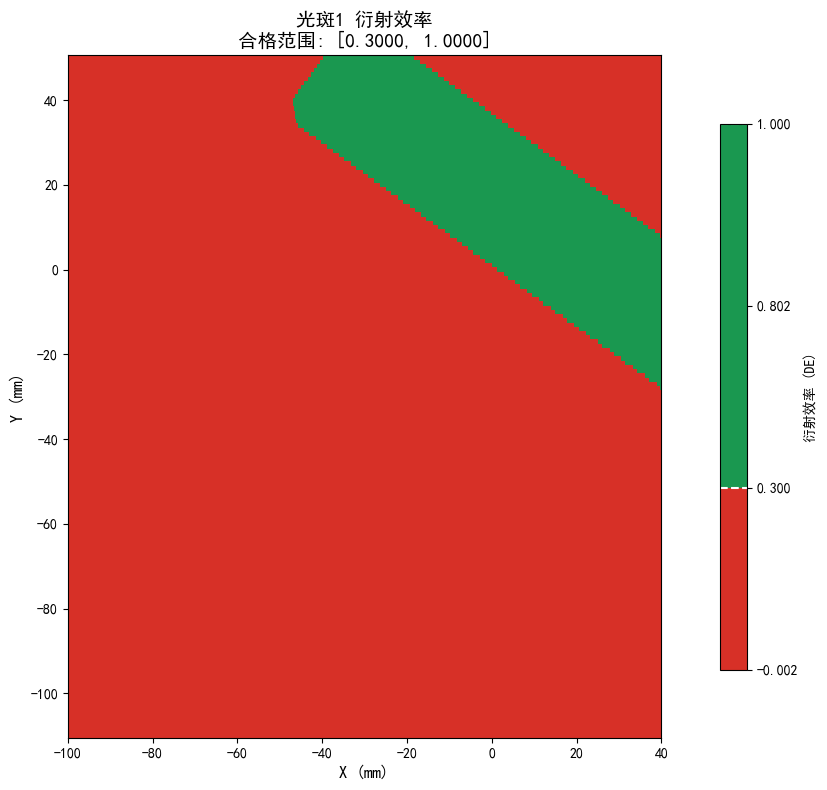

In [16]:

result = analyze_spot_heatmap("光斑1")
spot = result["spot"]
de = result["diffraction_efficiency"]
x_grid = result["x_grid"]
y_grid = result["y_grid"]
grid_2d = result["grid_2d"]
fig = result["figure"]
fig.show()

分析光斑: 光斑2
  入射光: 通道6 (效率系数=1.0)
  反射光: 通道10 (效率系数=2.15598)

衍射效率统计:
  最小值: -0.0036
  最大值: 0.8605
  平均值: 0.0083

正在构建网格...
网格大小: (1676, 16001) (Y × X)


C:\Users\ning.wang\AppData\Local\Temp\ipykernel_36516\1165430419.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


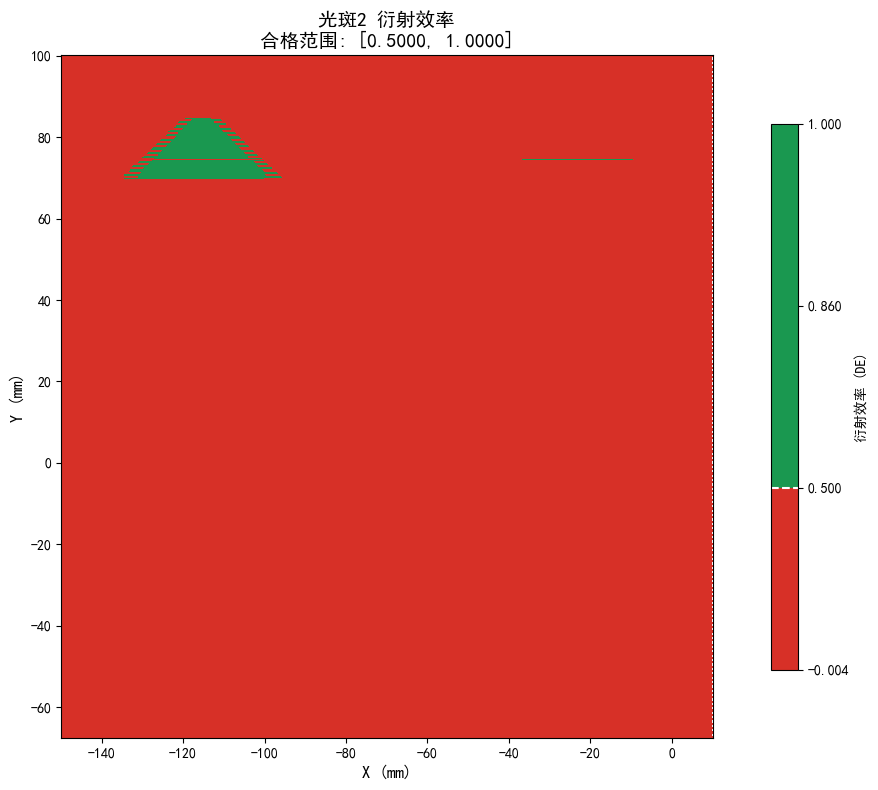

In [9]:

result = analyze_spot_heatmap("光斑2")
spot = result["spot"]
de = result["diffraction_efficiency"]
x_grid = result["x_grid"]
y_grid = result["y_grid"]
grid_2d = result["grid_2d"]
fig = result["figure"]
fig.show()

In [ ]:

result = analyze_spot_heatmap("光斑3")
spot = result["spot"]
de = result["diffraction_efficiency"]
x_grid = result["x_grid"]
y_grid = result["y_grid"]
grid_2d = result["grid_2d"]
fig = result["figure"]
fig.show()

In [ ]:

result = analyze_spot_heatmap("光斑4")
spot = result["spot"]
de = result["diffraction_efficiency"]
x_grid = result["x_grid"]
y_grid = result["y_grid"]
grid_2d = result["grid_2d"]
fig = result["figure"]
fig.show()

## 4. 差分热力图

选择两个光斑，输入位置偏移 (dx, dy)，计算差分并绘制。  
差分 = 光斑A的衍射效率 - 光斑B的衍射效率（偏移对齐后）

In [ ]:
# ========================
# 在这里配置差分参数
# ========================
SPOT_A_NAME = "光斑1"  # 第一个光斑
SPOT_B_NAME = "光斑2"  # 第二个光斑
DX = 0.0               # X 方向位置偏移 (mm)
DY = 0.0               # Y 方向位置偏移 (mm)

# 获取配置
spot_a = config.get_spot_by_name(SPOT_A_NAME)
spot_b = config.get_spot_by_name(SPOT_B_NAME)
if spot_a is None:
    raise ValueError(f"未找到光斑 '{SPOT_A_NAME}'，可用: {config.get_spot_names()}")
if spot_b is None:
    raise ValueError(f"未找到光斑 '{SPOT_B_NAME}'，可用: {config.get_spot_names()}")

print(f"差分分析: {spot_a.name} - {spot_b.name}")
print(f"位置偏移: dx={DX}, dy={DY}")

# 计算差分
print("\n正在计算差分（可能需要一些时间）...")
x_diff, y_diff, diff_grid = compute_differential(
    df, spot_a, spot_b, dx=DX, dy=DY,
)

import numpy as np
valid = diff_grid[~np.isnan(diff_grid)]
print(f"差分网格大小: {diff_grid.shape}")
print(f"差分统计:")
print(f"  最小值: {valid.min():.4f}")
print(f"  最大值: {valid.max():.4f}")
print(f"  平均值: {valid.mean():.4f}")
print(f"  标准差: {valid.std():.4f}")

# 绘制差分热力图
fig = plot_diff_heatmap_mpl(
    x_diff, y_diff, diff_grid,
    title=f"差分: {spot_a.name} - {spot_b.name} (偏移 dx={DX}, dy={DY})",
)
fig.show()

## 5. 离线光斑标定（亚网格拟合）

本节整合 Streamlit 版本的离线标定能力：
- 按阈值提取光栅区域
- 亚网格边界点拟合旋转矩形
- 输出中心、面积、角度、拟合质量
- 绘制与 Web 端一致的交互式拟合图


In [ ]:
import pandas as pd
import plotly.io as pio

from analysis import calibrate_grating_rectangle, compute_diffraction_efficiency, build_grid
from visualization import plot_calibration_result_plotly

# 使用 notebook_connected 渲染器，确保 Plotly 图可交互
pio.renderers.default = "notebook_connected"

def plot_spot_calibration_result(
    df,
    app_config,
    spot_name: str,
    threshold_min: float,
    threshold_max: float,
    median_kernel_size: int = 3,
    min_component_points: int = 30,
    roi=None,
    expected_size=None,
):
    """
    绘制指定光斑名称的离线标定拟合结果（交互式 Plotly）。

    Parameters
    ----------
    df : pandas.DataFrame
        扫描数据，需包含 x/y/ch* 列。
    app_config : AppConfig
        光斑配置。
    spot_name : str
        光斑名称，例如 "光斑3"。
    threshold_min / threshold_max : float
        光栅区域阈值上下限。

    Returns
    -------
    result, fig
        标定结果对象与 Plotly 图。
    """
    spot_cfg = app_config.get_spot_by_name(spot_name)
    if spot_cfg is None:
        raise ValueError(f"未找到光斑配置: {spot_name}")

    de = compute_diffraction_efficiency(df, spot_cfg)
    x_grid, y_grid, de_grid = build_grid(df["x"].values, df["y"].values, de)

    result = calibrate_grating_rectangle(
        x_grid=x_grid,
        y_grid=y_grid,
        de_grid=de_grid,
        threshold_min=threshold_min,
        threshold_max=threshold_max,
        median_kernel_size=median_kernel_size,
        min_component_points=min_component_points,
        roi=roi,
        expected_size=expected_size,
    )

    fig = plot_calibration_result_plotly(
        x=x_grid,
        y=y_grid,
        grid=result.smoothed_grid,
        corners=result.corners,
        center=(result.center_x, result.center_y),
        threshold_mask=result.threshold_mask,
        selected_mask=result.selected_mask,
        threshold_range=(threshold_min, threshold_max),
        title=f"{spot_name} 光栅拟合结果",
    )

    fig.show()
    return result, fig


def summarize_offline_calibration(
    df,
    app_config,
    spot_names,
    threshold_min: float,
    threshold_max: float,
    median_kernel_size: int = 3,
    min_component_points: int = 30,
    roi=None,
    expected_size=None,
):
    """批量执行离线标定并返回结果表。"""
    rows = []
    for spot_name in spot_names:
        try:
            result, _ = plot_spot_calibration_result(
                df=df,
                app_config=app_config,
                spot_name=spot_name,
                threshold_min=threshold_min,
                threshold_max=threshold_max,
                median_kernel_size=median_kernel_size,
                min_component_points=min_component_points,
                roi=roi,
                expected_size=expected_size,
            )
            rows.append({
                "光斑": spot_name,
                "状态": "部分覆盖（触边）" if result.is_partial else "正常",
                "中心X(mm)": result.center_x,
                "中心Y(mm)": result.center_y,
                "矩形宽(mm)": result.width,
                "矩形高(mm)": result.height,
                "矩形面积(mm²)": result.area,
                "区域面积(mm²)": result.mask_area,
                "填充率": result.fill_ratio,
                "角度(°)": result.angle_deg,
                "边界亚网格点数": result.boundary_point_count,
            })
        except Exception as e:
            rows.append({
                "光斑": spot_name,
                "状态": f"失败: {e}",
            })
    return pd.DataFrame(rows)


In [ ]:
# ========================
# 离线标定示例（可直接改参数后运行）
# ========================
CALIB_SPOT_NAME = "光斑3"
CALIB_THRESHOLD_MIN = 0.5
CALIB_THRESHOLD_MAX = 1.0
CALIB_MEDIAN_KERNEL = 3
CALIB_MIN_COMPONENT_POINTS = 30
CALIB_ROI = None  # 例如 (-60, 60, -40, 60)
CALIB_EXPECTED_SIZE = None  # 例如 (80.0, 35.0)

result, fig = plot_spot_calibration_result(
    df=df,
    app_config=config,
    spot_name=CALIB_SPOT_NAME,
    threshold_min=CALIB_THRESHOLD_MIN,
    threshold_max=CALIB_THRESHOLD_MAX,
    median_kernel_size=CALIB_MEDIAN_KERNEL,
    min_component_points=CALIB_MIN_COMPONENT_POINTS,
    roi=CALIB_ROI,
    expected_size=CALIB_EXPECTED_SIZE,
)

print("离线标定结果:")
print(f"  中心: ({result.center_x:.4f}, {result.center_y:.4f}) mm")
print(f"  尺寸: {result.width:.4f} x {result.height:.4f} mm")
print(f"  面积: {result.area:.4f} mm²")
print(f"  角度: {result.angle_deg:.4f}°")
print(f"  填充率: {result.fill_ratio:.4f}")
print(f"  边界亚网格点数: {result.boundary_point_count}")
print(f"  是否触边: {result.is_partial}")
